# Baseline XGBoost

## 1- Importation des bibliothèques

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier


## 2- Chargement des données

In [16]:
X = np.load("../data/processed/X_fraude.npy", allow_pickle=True)
y_fraude = np.load("../data/processed/y_fraude.npy", allow_pickle=True).ravel()

print("Shapes des données :")
print("X :", X.shape)
print("y_fraude :", y_fraude.shape)
print("Exemples de labels :", np.unique(y_fraude))


Shapes des données :
X : (17143, 43)
y_fraude : (17143,)
Exemples de labels : ['account_takeover' 'atm_fraud' 'card_not_present' 'card_present_stolen'
 'friendly_fraud' 'identity_theft' 'money_laundering']


## 3- Encodage des labels

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_fraude)

print("Labels encodés :", np.unique(y_encoded))


Labels encodés : [0 1 2 3 4 5 6]


## 4- Séparation des données entraînement/test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTaille entraînement/test :")
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)



Taille entraînement/test :
X_train : (13714, 43)
X_test : (3429, 43)
y_train : (13714,)
y_test : (3429,)


## 5- Définition du modèle XGBoost et GridSearchCV

In [19]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01],
    'subsample': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nDébut GridSearchCV...")
grid_search.fit(X_train, y_train)

print("GridSearchCV terminé !")
print("Meilleurs paramètres :", grid_search.best_params_)

best_model = grid_search.best_estimator_



Début GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
GridSearchCV terminé !
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


## 6- Évaluation du modèle

In [21]:
y_pred = best_model.predict(X_test)

print("\nClassification report :")

print(classification_report(y_test,y_pred,target_names=le.classes_))


Classification report :
                     precision    recall  f1-score   support

   account_takeover       0.47      0.17      0.25       687
          atm_fraud       0.00      0.00      0.00       243
   card_not_present       0.37      0.90      0.53      1197
card_present_stolen       0.21      0.02      0.04       624
     friendly_fraud       0.26      0.02      0.03       345
     identity_theft       0.00      0.00      0.00       131
   money_laundering       0.58      0.60      0.59       202

           accuracy                           0.39      3429
          macro avg       0.27      0.24      0.21      3429
       weighted avg       0.32      0.39      0.28      3429



C:\Users\Alan\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alan\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alan\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

## 7- ROC multi-classes

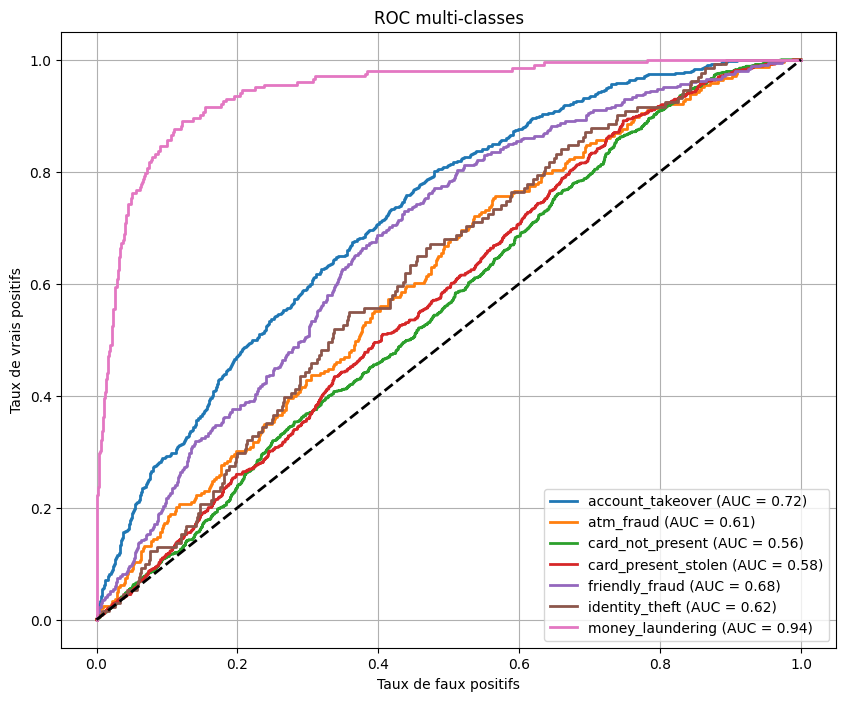

Courbe ROC sauvegardée : ../reports/roc_multiclass.png


In [22]:
classes = np.arange(len(le.classes_))

y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(10, 8))

for i, class_label in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{class_label} (AUC = {roc_auc:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('ROC multi-classes')
plt.legend(loc='lower right')
plt.grid(True)

plt.savefig('../reports/roc_multiclass.png')
plt.show()

print('Courbe ROC sauvegardée : ../reports/roc_multiclass.png')


## 8- Precision-Recall multi-classes

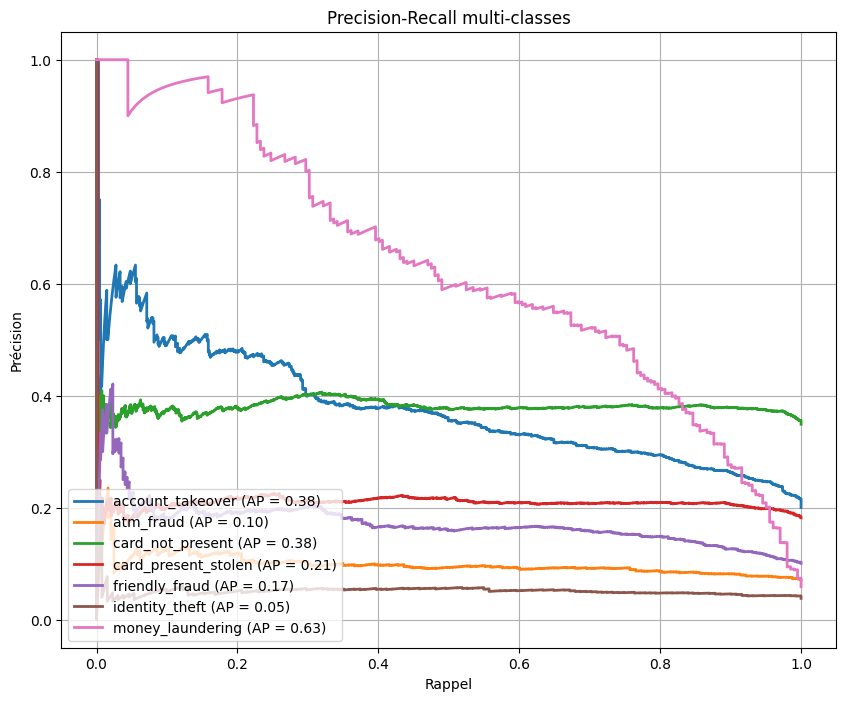

Courbe Precision-Recall sauvegardée : ../reports/precision_recall_multiclass.png


In [23]:
plt.figure(figsize=(10, 8))

for i, class_label in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

    plt.plot(
        recall,
        precision,
        lw=2,
        label=f'{class_label} (AP = {avg_precision:.2f})'
    )

plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title('Precision-Recall multi-classes')
plt.legend(loc='lower left')
plt.grid(True)

plt.savefig('../reports/precision_recall_multiclass.png')
plt.show()

print('Courbe Precision-Recall sauvegardée : ../reports/precision_recall_multiclass.png')


## 9- Matrice de confusion

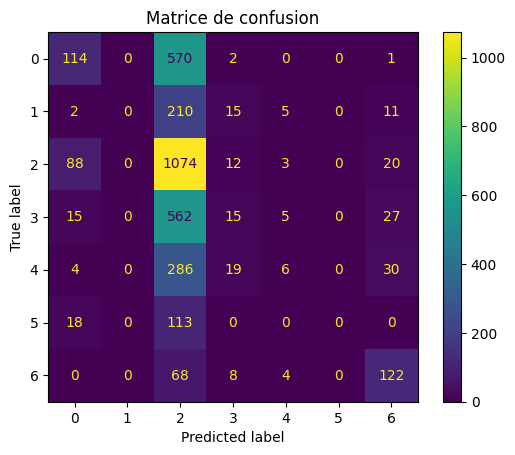

In [24]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Matrice de confusion")

plt.savefig('../reports/matrice_confusion.png')
plt.show()


## 10- Sauvegarde du modèle

In [25]:
joblib.dump(best_model, '../models/saved/xgboost_baseline_model.pkl')
joblib.dump(le, '../models/saved/label_encoder.pkl')

print('Modèle XGBoost et LabelEncoder sauvegardés dans ../models/saved/')

Modèle XGBoost et LabelEncoder sauvegardés dans ../models/saved/
